# 🏏 IPL Data Analysis (EDA)

This notebook explores IPL player performance data.

## Objectives:
- Understand data distribution
- Analyze player performance trends
- Identify insights for ML modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/final_dataset.csv')
df.head()

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,match_id,batter,runs,balls_faced,match_date,avg_last_5,avg_last_10,strike_rate,match_number,consistency,form_trend
0,548346.0,A Ashish Reddy,10.0,10,1970-01-01 00:00:00.000548346,0.0,0.0,100.0,0,0.000000,0.000000
1,548352.0,A Ashish Reddy,3.0,3,1970-01-01 00:00:00.000548352,0.0,0.0,100.0,1,0.000000,0.000000
2,548359.0,A Ashish Reddy,8.0,8,1970-01-01 00:00:00.000548359,0.0,0.0,100.0,2,0.000000,0.000000
3,548373.0,A Ashish Reddy,10.0,4,1970-01-01 00:00:00.000548373,0.0,0.0,250.0,3,0.000000,0.000000
4,548376.0,A Ashish Reddy,4.0,5,1970-01-01 00:00:00.000548376,7.0,0.0,80.0,4,3.316625,0.333333


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17638 entries, 0 to 17637
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   match_id      17638 non-null  float64
 1   batter        17638 non-null  object 
 2   runs          17638 non-null  float64
 3   balls_faced   17638 non-null  int64  
 4   match_date    17638 non-null  object 
 5   avg_last_5    17638 non-null  float64
 6   avg_last_10   17638 non-null  float64
 7   strike_rate   17638 non-null  float64
 8   match_number  17638 non-null  int64  
 9   consistency   17638 non-null  float64
 10  form_trend    17638 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 1.5+ MB


,match_id,runs,balls_faced,avg_last_5,avg_last_10,strike_rate,match_number,consistency,form_trend
count,1.763800e+04,17638.000000,17638.000000,17638.000000,17638.000000,17638.000000,17638.000000,17638.000000,17638.000000
mean,9.438858e+05,20.148146,15.773047,18.544540,16.799790,110.319881,44.374702,15.244598,-0.051140
std,3.834562e+05,21.488988,13.896944,13.650526,13.222992,66.748290,47.518682,11.091097,8.986030
min,3.359820e+05,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-52.333333
25%,5.483530e+05,4.000000,5.000000,7.800000,1.800000,66.666667,9.000000,6.610598,-4.000000
50%,1.082604e+06,13.000000,11.000000,17.400000,17.500000,109.090909,27.000000,14.230248,0.000000
75%,1.304056e+06,30.000000,23.000000,27.400000,26.300000,148.484848,65.000000,22.615260,4.000000
max,1.485779e+06,175.000000,77.000000,83.000000,69.000000,600.000000,265.000000,70.651964,57.000000


## 🔥 Top Players by Average Runs

In [3]:
top_players = df.groupby('batter')['runs'].mean().sort_values(ascending=False).head(10)
top_players

batter
Vivrant Sharma     69.000000
B Sai Sudharsan    44.825000
KL Rahul           38.777778
DP Conway          38.571429
LMP Simmons        37.206897
SE Marsh           36.072464
HM Amla            36.062500
V Suryavanshi      36.000000
RD Gaikwad         35.742857
DA Warner          35.690217
Name: runs, dtype: float64

## 📈 Player Performance Trend

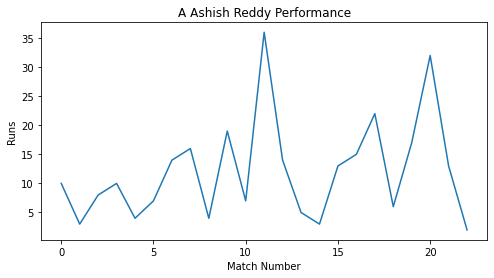

In [4]:
player = df['batter'].iloc[0]
player_df = df[df['batter'] == player]

plt.figure(figsize=(8, 4))
plt.plot(
    player_df['match_number'].values,
    player_df['runs'].values
)

plt.title(f'{player} Performance')
plt.xlabel('Match Number')
plt.ylabel('Runs')
plt.show()

## 📊 Distribution of Runs

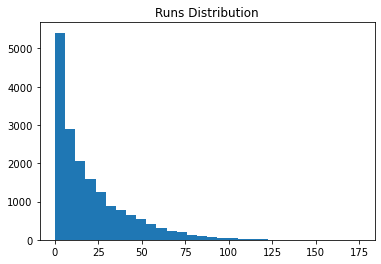

In [5]:
plt.hist(df['runs'], bins=30)
plt.title('Runs Distribution')
plt.show()

## 🔗 Feature Correlation

In [6]:
corr = df[['runs','avg_last_5','avg_last_10','strike_rate']].corr()
corr

,runs,avg_last_5,avg_last_10,strike_rate
runs,1.000000,0.527656,0.404531,0.494829
avg_last_5,0.527656,1.000000,0.799604,0.220101
avg_last_10,0.404531,0.799604,1.000000,0.156756
strike_rate,0.494829,0.220101,0.156756,1.000000


## 🔗 Player Consistency

In [7]:
df.groupby('batter')['runs'].std().sort_values().head(10)

batter
CRD Fernando        0.000000
R Minz              0.000000
JP Behrendorff      0.000000
RP Meredith         0.000000
Akash Madhwal       0.000000
S Ladda             0.000000
SB Joshi            0.000000
KK Ahmed            0.516398
A Singh             0.547723
Fazalhaq Farooqi    0.577350
Name: runs, dtype: float64

## 🔗 Strike Rate vs Runs

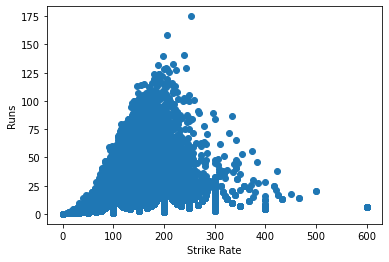

In [8]:
plt.scatter(df['strike_rate'], df['runs'])
plt.xlabel("Strike Rate")
plt.ylabel("Runs")
plt.show()

## 🔗 Top 10 Consistent Players

In [9]:
consistency = df.groupby('batter')['runs'].std().sort_values().head(10)
consistency

batter
CRD Fernando        0.000000
R Minz              0.000000
JP Behrendorff      0.000000
RP Meredith         0.000000
Akash Madhwal       0.000000
S Ladda             0.000000
SB Joshi            0.000000
KK Ahmed            0.516398
A Singh             0.547723
Fazalhaq Farooqi    0.577350
Name: runs, dtype: float64

## 🔗 Rolling Average Visualization

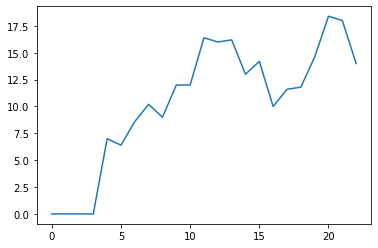

In [10]:
player_df['avg_last_5'].plot()